<a href="https://colab.research.google.com/github/Vishalization/Skin_Disease_Classification/blob/main/Vishal_EfficientNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:


from google.colab import drive
drive.mount('/content/drive')



Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/skin_split.rar" /content/

In [3]:
!ls /content

drive  sample_data  skin_split.rar


In [4]:
!apt-get install unrar
!unrar x /content/skin_split.rar /content/

Streaming output truncated to the last 5000 lines.
Extracting  /content/skin_split/train/nv/ISIC_0025194.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025198.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025200.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025201.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025202.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025203.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025204.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025205.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025206.jpg                 50%  OK 
Extracting  /content/skin_split/train/nv/ISIC_0025207.jpg                 50%  OK 
Extracting  /content/skin_spl

In [5]:
import os
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import sklearn

In [6]:

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import efficientnet
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report
from tensorflow.keras.applications.efficientnet import preprocess_input

In [7]:
# path for training and testing data
train_dir = "/content/skin_split/train"
test_dir = "/content/skin_split/test"

In [8]:
# data augmentation for training data
train_datagen = ImageDataGenerator(
   preprocessing_function=preprocess_input,
   rotation_range=30,
   width_shift_range=0.1,
   height_shift_range=0.1,
   shear_range=0.1,
   zoom_range=0.2,
   horizontal_flip=True,
   fill_mode='nearest',
   validation_split=0.15
)

In [9]:
# generate data for training and validation data set
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    seed=42
)

Found 6813 images belonging to 7 classes.
Found 1197 images belonging to 7 classes.


In [10]:
test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(256,256),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

Found 2005 images belonging to 7 classes.


In [11]:
#class weight as the HAM10000 is imbalance
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights using training labels
classes = np.unique(train_generator.classes)

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=train_generator.classes
)

class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(4.384169884169884), 1: np.float64(2.780816326530612), 2: np.float64(1.3011841100076393), 3: np.float64(12.320072332730561), 4: np.float64(1.2857142857142858), 5: np.float64(0.21343984962406015), 6: np.float64(10.033873343151694)}


In [12]:
# model download and configuration
from tensorflow.keras.applications import *
from tensorflow.keras.layers import Flatten, Dense, Input, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import BatchNormalization

base_model = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(256, 256, 3))

for layer in base_model.layers :
    layer.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)

x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.4)(x)

x = BatchNormalization()(x)
x = Dense(256, activation='relu', kernel_regularizer='l2')(x)
x = Dropout(0.3)(x)

x = Dense(7, activation='softmax')(x)

tl_model = Model(inputs=base_model.input, outputs=x)


tl_model.summary()


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling           │ (None, 256, 256,  │          0 │ input_layer[0][0] │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ normalization       │ (None, 256, 256,  │          7 │ rescaling[0][0]   │
│ (Normalization)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ rescaling_1         │ (None, 256, 256,  │          0 │ normalization[0]… │
│ (Rescaling)         │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv_pad       │ (None, 257, 257,  │          0 │ rescaling_1[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_conv (Conv2D)  │ (None, 128, 128,  │        864 │ stem_conv_pad[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_bn             │ (None, 128, 128,  │        128 │ stem_conv[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stem_activation     │ (None, 128, 128,  │          0 │ stem_bn[0][0]     │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_dwconv      │ (None, 128, 128,  │        288 │ stem_activation[… │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_bn          │ (None, 128, 128,  │        128 │ block1a_dwconv[0… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_activation  │ (None, 128, 128,  │          0 │ block1a_bn[0][0]  │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_squeeze  │ (None, 32)        │          0 │ block1a_activati… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reshape  │ (None, 1, 1, 32)  │          0 │ block1a_se_squee… │
│ (Reshape)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_reduce   │ (None, 1, 1, 8)   │        264 │ block1a_se_resha… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_expand   │ (None, 1, 1, 32)  │        288 │ block1a_se_reduc… │
│ (Conv2D)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_se_excite   │ (None, 128, 128,  │          0 │ block1a_activati… │
│ (Multiply)          │ 32)               │            │ block1a_se_expan… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1a_project_co… │ (None, 128, 128,  │        512 │ block1a_se_excit

 Total params: 4,845,738 (18.49 MB)

 Trainable params: 792,583 (3.02 MB)

 Non-trainable params: 4,053,155 (15.46 MB)

In [13]:
#optimizer
optimizer = Adam(1e-4)
tl_model.compile(loss="categorical_crossentropy", optimizer=optimizer, metrics=["accuracy"])

In [14]:
# LearningRate; EarlyStopping; ModelCheckpoint
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    "best_efficent_skin_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

callbacks = [lr_reduce, early_stop, checkpoint]

In [15]:

#first training training or compiling
history = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=12,
    callbacks=callbacks,
    class_weight=class_weights
)



Epoch 1/12
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 757ms/step - accuracy: 0.1660 - loss: 5.8087
Epoch 1: val_accuracy improved from None to 0.54804, saving model to best_efficent_skin_model.keras

Epoch 1: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 243s 987ms/step - accuracy: 0.2112 - loss: 5.5318 - val_accuracy: 0.5480 - val_loss: 4.7277 - learning_rate: 1.0000e-04
Epoch 2/12
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 665ms/step - accuracy: 0.3200 - loss: 5.0187
Epoch 2: val_accuracy did not improve from 0.54804
213/213 ━━━━━━━━━━━━━━━━━━━━ 166s 780ms/step - accuracy: 0.3320 - loss: 4.9211 - val_accuracy: 0.5205 - val_loss: 4.4934 - learning_rate: 1.0000e-04
Epoch 3/12
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 672ms/step - accuracy: 0.3869 - loss: 4.6974
Epoch 3: val_accuracy did not improve from 0.54804
213/213 ━━━━━━━━━━━━━━━━━━━━ 167s 782ms/step - accuracy: 0.3922 - loss: 4.6341 - val_accuracy: 0.5464 - val_loss: 4.3135 - learning_rate: 1.0000e-04
Epoch 4/12
213/213 ━━

In [16]:
# unfreeze last layers for fine tuning
for layer in base_model.layers[-40:]:
    layer.trainable = True

from tensorflow.keras.optimizers import Adam

tl_model.compile(
 optimizer=Adam(1e-5),
 loss='categorical_crossentropy',
 metrics=['accuracy']
)

fine_tune_history = tl_model.fit(
 train_generator,
 validation_data=val_generator,
 epochs=10,
 callbacks=callbacks,
 class_weight=class_weights
)

Epoch 1/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 723ms/step - accuracy: 0.4826 - loss: 3.4014
Epoch 1: val_accuracy did not improve from 0.61320
213/213 ━━━━━━━━━━━━━━━━━━━━ 232s 933ms/step - accuracy: 0.4902 - loss: 3.3550 - val_accuracy: 0.5923 - val_loss: 3.0513 - learning_rate: 1.0000e-05
Epoch 2/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.4807 - loss: 3.2667
Epoch 2: ReduceLROnPlateau reducing learning rate to 2.9999999242136253e-06.

Epoch 2: val_accuracy did not improve from 0.61320
213/213 ━━━━━━━━━━━━━━━━━━━━ 164s 770ms/step - accuracy: 0.4836 - loss: 3.2941 - val_accuracy: 0.5898 - val_loss: 3.0476 - learning_rate: 1.0000e-05
Epoch 3/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 656ms/step - accuracy: 0.4668 - loss: 3.1999
Epoch 3: val_accuracy did not improve from 0.61320
213/213 ━━━━━━━━━━━━━━━━━━━━ 163s 767ms/step - accuracy: 0.4767 - loss: 3.2263 - val_accuracy: 0.5773 - val_loss: 3.0810 - learning_rate: 3.0000e-06
Epoch 4/10
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 649ms/step - ac

In [17]:
from tensorflow.keras.models import load_model

tl_model = load_model("best_efficent_skin_model.keras")

In [18]:
for layer in tl_model.layers[-15:]:
    layer.trainable = True

In [19]:
from tensorflow.keras.optimizers import Adam

tl_model.compile(
    optimizer=Adam(5e-6),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [20]:
fine_history_2 = tl_model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=8,
    callbacks=callbacks,
    class_weight=class_weights
)

Epoch 1/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 690ms/step - accuracy: 0.5275 - loss: 3.3755
Epoch 1: val_accuracy did not improve from 0.61320
213/213 ━━━━━━━━━━━━━━━━━━━━ 211s 871ms/step - accuracy: 0.5256 - loss: 3.3682 - val_accuracy: 0.6065 - val_loss: 3.2222 - learning_rate: 5.0000e-06
Epoch 2/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.5278 - loss: 3.4326
Epoch 2: ReduceLROnPlateau reducing learning rate to 1.4999999621068127e-06.

Epoch 2: val_accuracy improved from 0.61320 to 0.61404, saving model to best_efficent_skin_model.keras

Epoch 2: finished saving model to best_efficent_skin_model.keras
213/213 ━━━━━━━━━━━━━━━━━━━━ 165s 776ms/step - accuracy: 0.5181 - loss: 3.3899 - val_accuracy: 0.6140 - val_loss: 3.2390 - learning_rate: 5.0000e-06
Epoch 3/8
213/213 ━━━━━━━━━━━━━━━━━━━━ 0s 653ms/step - accuracy: 0.5213 - loss: 3.3692
Epoch 3: val_accuracy did not improve from 0.61404
213/213 ━━━━━━━━━━━━━━━━━━━━ 164s 769ms/step - accuracy: 0.5183 - loss: 3.3453 - val_accurac

In [21]:
df=pd.DataFrame(tl_model.history.history)
df.to_csv('hist.csv')

<Axes: >

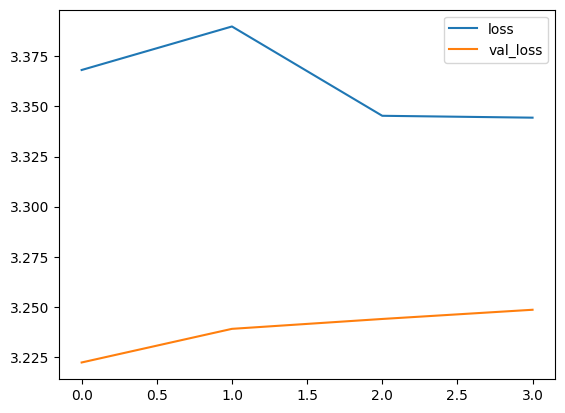

In [22]:
metrics = pd.DataFrame(tl_model.history.history)
metrics[["loss","val_loss"]].plot()

<Axes: >

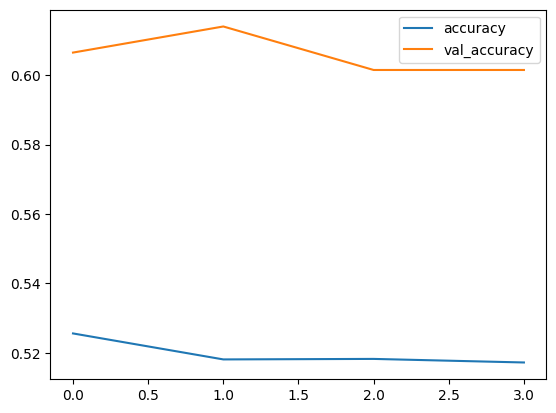

In [23]:
metrics[["accuracy","val_accuracy"]].plot()

In [24]:
tl_model.evaluate(test_generator)

63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 458ms/step - accuracy: 0.5696 - loss: 3.2948


[3.2947564125061035, 0.5695760846138]

In [25]:
predictions = tl_model.predict(test_generator, verbose=1)
predictions = predictions.argmax(axis=1)

test_labels = test_generator.classes

63/63 ━━━━━━━━━━━━━━━━━━━━ 29s 339ms/step


In [27]:
import sklearn
from sklearn.metrics import classification_report, confusion_matrix

cm = confusion_matrix(test_labels, predictions)

Normalized confusion matrix


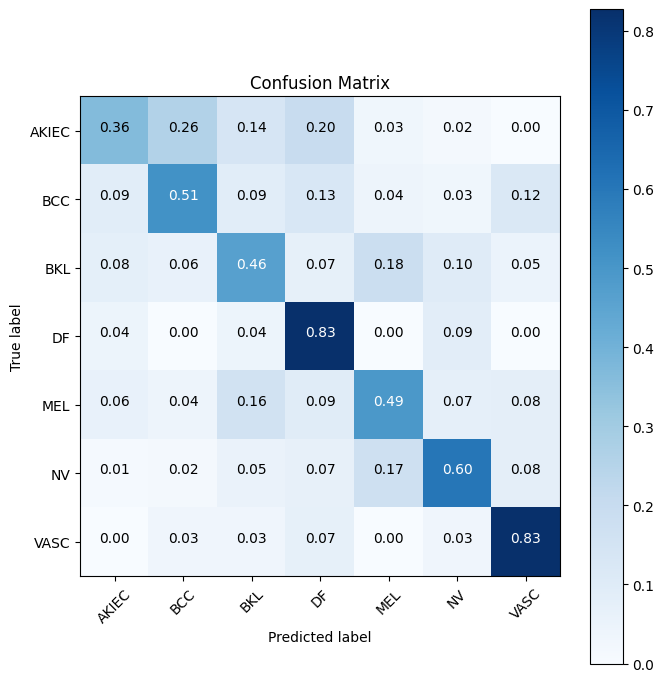

In [28]:
import itertools

def plot_confusion_matrix(cm, classes,
                          normalize=True,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')
        print(cm)

    plt.figure(figsize=(7,7))
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()


cm_plot_labels =['AKIEC','BCC','BKL','DF','MEL','NV','VASC']
plot_confusion_matrix(cm, cm_plot_labels, title='Confusion Matrix', normalize=True)


In [30]:
!pip install disarray
import disarray

# Instantiate the confusion matrix DataFrame with index and columns
#cm = confusion_matrix(a,b)
df = pd.DataFrame(cm, index= ['AKIEC','BCC','BKL','DF','MEL','NV','VASC'], columns=['AKIEC','BCC','BKL','DF','MEL','NV','VASC'])
df.da.export_metrics()

,AKIEC,BCC,BKL,DF,MEL,NV,VASC,micro-average
accuracy,0.951122,0.943641,0.878803,0.921696,0.806983,0.712718,0.924190,0.877022
f1,0.328767,0.484018,0.456376,0.194872,0.362438,0.737705,0.240000,0.569576
false_discovery_rate,0.700000,0.543103,0.550661,0.889535,0.713542,0.052632,0.859649,0.430424
false_negative_rate,0.636364,0.485437,0.536364,0.173913,0.506726,0.395973,0.172414,0.430424
false_positive_rate,0.028881,0.033123,0.070028,0.077195,0.153760,0.067771,0.074393,0.071737
negative_predictive_value,0.978182,0.973531,0.933633,0.997818,0.930290,0.538261,0.997274,0.928263
positive_predictive_value,0.300000,0.456897,0.449339,0.110465,0.286458,0.947368,0.140351,0.569576
precision,0.300000,0.456897,0.449339,0.110465,0.286458,0.947368,0.140351,0.569576
recall,0.363636,0.514563,0.463636,0.826087,0.493274,0.604027,0.827586,0.569576
sensitivity,0.363636,0.514563,0.463636,0.826087,0.493274,0.604027,0.827586,0.569576
